   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Weights : [1.56072066 1.9971184 ]
Bias : -2.1739999999998716
Accuracy : 0.9533333333333334

Prediction : Iris-virginica


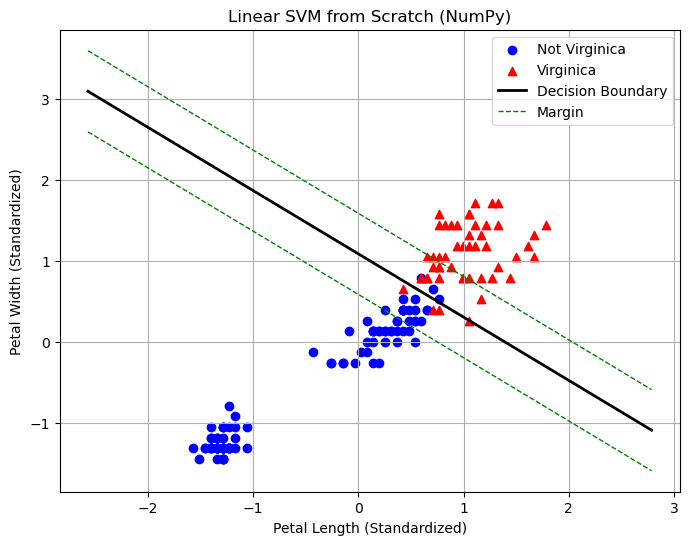

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Load Dataset
df = pd.read_csv("Iris.csv")
print(df.head())
# Select Features
X = df[['PetalLengthCm', 'PetalWidthCm']].values
# Binary Classification
# Iris-virginica = +1
# Others = -1
y = np.where(df['Species'] == 'Iris-virginica', 1, -1)
# Feature Scaling
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = (X - mean) / std
# Parameters
learning_rate = 0.001
lambda_param = 0.01
epochs = 1000
# Initialize
w = np.zeros(X.shape[1])
b = 0
# Training
for epoch in range(epochs):
    for i, x_i in enumerate(X):
        condition = y[i] * (np.dot(x_i, w) + b) >= 1
        if condition:
            dw = 2 * lambda_param * w
            db = 0
        else:
            dw = 2 * lambda_param * w - y[i] * x_i
            db = -y[i]
        w = w - learning_rate * dw
        b = b - learning_rate * db
# Prediction
predictions = np.sign(np.dot(X, w) + b)
# Accuracy
accuracy = np.mean(predictions == y)
print("\nWeights :", w)
print("Bias :", b)
print("Accuracy :", accuracy)
# Predict New Flower
new_flower = np.array([[5.5, 1.7]])
# Scale using training statistics
new_flower = (new_flower - mean) / std
prediction = np.sign(np.dot(new_flower, w) + b)
if prediction == 1:
    print("\nPrediction : Iris-virginica")
else:
    print("\nPrediction : Not Iris-virginica")
# Visualization
plt.figure(figsize=(8,6))
plt.scatter(
    X[y==-1][:,0],
    X[y==-1][:,1],
    color='blue',
    marker='o',
    label='Not Virginica'
)
plt.scatter(
    X[y==1][:,0],
    X[y==1][:,1],
    color='red',
    marker='^',
    label='Virginica'
)
# Decision Boundary
x1 = np.linspace(
    np.min(X[:,0])-1,
    np.max(X[:,0])+1,
    100
)
decision = -(w[0]*x1 + b)/w[1]
margin1 = -(w[0]*x1 + b -1)/w[1]
margin2 = -(w[0]*x1 + b +1)/w[1]
plt.plot(
    x1,
    decision,
    'k-',
    linewidth=2,
    label='Decision Boundary'
)
plt.plot(
    x1,
    margin1,
    'g--',
    linewidth=1,
    label='Margin'
)

plt.plot(
    x1,
    margin2,
    'g--',
    linewidth=1
)
plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Linear SVM from Scratch (NumPy)")
plt.legend()
plt.grid(True)
plt.show()